In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch 

from torch.utils.data import TensorDataset,DataLoader
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
print(os.listdir('../data'))

['bathymetry_EASE.csv', 'DRIFT_DATA_FULL.csv', 'DRIFT_DATA_FULL_hackathon.csv', 'DRIFT_DATA_TEST.csv', 'DRIFT_DATA_TEST_ans.csv', 'DRIFT_DATA_TRAIN.csv', 'latitude_EASE.csv', 'longitude_EASE.csv', 'README.txt']


,year,month,day,doy,x_EASE,y_EASE,u_buoy,v_buoy,id_buoy,u_ERA5,v_ERA5,sic_CDR,h_piomas
0,1979,2,18,49,197.656311,204.507797,4.514760,12.047400,1905,5.998414,3.617303,0.987723,2.535649
1,1979,2,18,49,147.506958,138.582672,-0.797554,1.114740,1906,-6.704156,-0.321260,0.990195,3.189743
2,1979,2,18,49,146.834778,120.509880,0.643200,0.368754,1913,-6.818630,-0.674205,0.966372,2.484009
3,1979,2,18,49,130.993561,129.623672,-1.162420,0.243717,1914,-8.825469,1.123955,0.996022,2.474106
4,1979,2,18,49,147.524719,157.382492,0.919766,0.025784,1918,-1.079951,-1.035410,0.982681,3.740522
...,...,...,...,...,...,...,...,...,...,...,...,...,...
339151,2019,12,30,364,200.005966,174.816803,-1.894280,-0.864665,16210,-1.934895,-1.281953,1.000000,1.467497
339152,2019,12,30,364,173.589722,117.012932,-13.455300,-10.662800,25560,-7.082469,-4.199740,1.000000,1.061049
339153,2019,12,30,364,208.421234,142.049896,-7.247925,-5.289890,53005,-4.615093,-0.381765,1.000000,1.288953
339154,2019,12,30,364,145.264023,146.109741,-0.913761,2.182150,95020,1.940967,1.119087,1.000000,1.960349


In [132]:
# DATA LOADER
trainpd=pd.read_csv('../data/DRIFT_DATA_TRAIN.csv')
trainpd
bs = 64 # batch size

trainpd=trainpd.drop(['year','month','day','x_EASE','y_EASE','id_buoy'],axis=1) #unwanted quantities



# NORMALIZATION STEP
#for day of year, simply divide by 364 to get smth between 0 and 1 (order 1)
trainpd['doy']=trainpd['doy']/364

# for the speeds, we substract the mean and divide by the standard deviation to get some cleaner distribution
speeds=['u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5']

means={}
stds={}
for label in speeds:
    means[label]=trainpd[label].mean()
    stds[label]=trainpd[label].std()
    trainpd[label]=(trainpd[label]-trainpd[label].mean())/trainpd[label].std()



# SIC is already [0,1] and sea ice thickness is typically between 0 and idk 5 nothing is needed



target = pd.DataFrame([trainpd['u_buoy'],trainpd['v_buoy']]).T# had to reshape from u,v x rows to rows x u,v

trainpd = trainpd.drop(['u_buoy', 'v_buoy'],axis=1) # Take away the time of the year, wrong dtype and seems to be useless anyway
labels = [target.columns, trainpd.columns]
# we keep the day of year tho

traintensor = torch.tensor(trainpd.values, dtype= torch.float32)
targetensor = torch.tensor(target.values, dtype= torch.float32) 
print(target.shape)
print(traintensor.shape)
trainset=TensorDataset(targetensor,traintensor)
trainloader=DataLoader(trainset,batch_size=bs,shuffle=True)

(339156, 2)
torch.Size([339156, 5])


In [133]:
print(labels)

[Index(['u_buoy', 'v_buoy'], dtype='object'), Index(['doy', 'u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas'], dtype='object')]


In [ ]:
# To validate the data, you can remove the u_buoy and v_buoy from the .drop in the previous cell
# and compare the data that comes out from the first tensor (the truth) and the conditional fields
example = next(iter(trainloader))
print(means)
print(stds)

{'u_buoy': np.float64(-0.32911380120878647), 'v_buoy': np.float64(1.3688631602290797), 'u_ERA5': np.float64(-0.09414265660210988), 'v_ERA5': np.float64(0.34181398888012804)}
{'u_buoy': 8.060844323805954, 'v_buoy': 7.8546459505739765, 'u_ERA5': 4.31685881983416, 'v_ERA5': 4.122204959702637}


In [6]:
# creating my neural network

class firstNN(nn.Module):
    """Hummmm"""
    def __init__(self, n_inputs):
        """GANG"""
        super().__init__()
        self.fc1=nn.Linear(n_inputs,128)
        self.fc2=nn.Linear(128,64)
        # self.fc3=nn.Linear(64,32)
        # self.fc4=nn.Linear(32,16)
        # self.fc5=nn.Linear(16,8)
        # self.fc6=nn.Linear(8,4)
        self.final=nn.Linear(64,2)

    def forward(self,x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        # x=F.sigmoid(self.fc3(x))
        # x=F.sigmoid(self.fc4(x))
        # x=F.sigmoid(self.fc5(x))
        # x=F.sigmoid(self.fc6(x))
        x=self.final(x)
        return x


babynet = firstNN(n_inputs=traintensor.shape[1])
print(babynet)

firstNN(
  (fc1): Linear(in_features=5, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (final): Linear(in_features=64, out_features=2, bias=True)
)


In [ ]:
# ALL RIGHT LETS TRY TO TRAIN THAT THING
import torch.optim as optim

# Hyperparameters
lr=1e-3
epoch=1

optimizer = optim.Adam(babynet.parameters(),lr=lr) # optimizers

def RMSE(target,outputs):
    '''Calculates the RMSE between, the target and the model outputs'''
    return (torch.mean((target-outputs)**2))**.5


losses=[]
rloss=0
rcount=0

for epoch in range(epoch):
    print('Epoch: ',epoch)
    curpercent=0
    for i,data in enumerate(trainloader):

        # get the inputs and the target
        truth,inputs= data[0],data[1]

        # zero the gradients,
        optimizer.zero_grad()

        # Forward,
        out=babynet(inputs)
        loss=RMSE(truth,out)

        # Backward
        loss.backward()
        losses.append(loss.item())
        # Optimize

        optimizer.step()
        rloss+= loss.item()
        rcount +=1
        #print where we at plus the loss
        percent= round(i/len(trainloader)*100)
        if percent != curpercent:
            print(percent, 'loss: ', rloss/rcount)
            curpercent=percent
            rloss=0
            rcount=0






Epoch:  0
1 loss:  0.44191479682922363
2 loss:  0.35087981820106506
3 loss:  0.4517715275287628
4 loss:  0.37095510959625244
5 loss:  0.44100630283355713
6 loss:  0.39127811789512634
7 loss:  0.5603644847869873
8 loss:  0.6702743172645569
9 loss:  0.2923697531223297
10 loss:  0.526386559009552
11 loss:  0.45486196875572205
12 loss:  0.5031836628913879
13 loss:  0.6245163679122925
14 loss:  0.41753560304641724
15 loss:  1.0966949462890625
16 loss:  0.3450896143913269
17 loss:  0.792130708694458
18 loss:  0.34074732661247253
19 loss:  0.31851667165756226
20 loss:  0.34256547689437866
21 loss:  0.7445900440216064
22 loss:  0.5817444920539856
23 loss:  0.1543971300125122
24 loss:  0.3086465895175934
25 loss:  0.3089347779750824
26 loss:  0.45811206102371216
27 loss:  0.29476678371429443
28 loss:  0.16348490118980408
29 loss:  0.9567433595657349
30 loss:  0.5400452017784119
31 loss:  0.355187326669693
32 loss:  1.3574243783950806
33 loss:  0.562958836555481
34 loss:  0.42362141609191895
35 

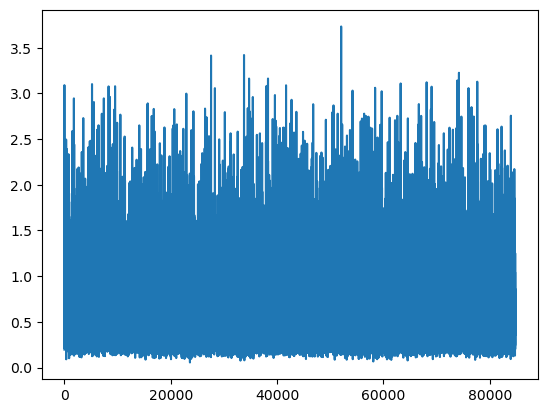

In [8]:
plt.plot(losses)

# Put it on GPU


In [4]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

print(device)

cuda


In [21]:
babygpu= firstNN(n_inputs=traintensor.shape[1]).to(device)
print(babygpu.parameters)

<bound method Module.parameters of firstNN(
  (fc1): Linear(in_features=5, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (final): Linear(in_features=64, out_features=2, bias=True)
)>


In [36]:
# ALL RIGHT LETS TRY TO TRAIN THAT THING
import torch.optim as optim

# Hyperparameters
lr=0.001
epoch=1

optimizer = optim.Adam(babygpu.parameters(),lr=lr) # optimizers
criterion = nn.MSELoss()

def RMSE(target,outputs):
    '''Calculates the RMSE between, the target and the model outputs'''
    return (torch.mean((target-outputs)**2))**.5

rlosses=[]
losses=[]
rloss=0
rcount=0


for epoch in range(epoch):
    print('Epoch: ',epoch)
    curpercent=0
    for i,data in enumerate(trainloader):

        # get the inputs and the target
        truth,inputs= data[0].to(device),data[1].to(device)

        # zero the gradients,
        optimizer.zero_grad()

        # Forward,
        out=babygpu(inputs)


        loss = criterion(out,truth)
        # Backward
        loss.backward()
        losses.append(loss.item())
        # Optimize

        optimizer.step()

        rloss+= loss.item()
        rcount +=1
        #print where we at plus the loss
        percent= round(i/len(trainloader)*100)
        if percent != curpercent:
            print(percent, 'loss: ', rloss/rcount)
            curpercent=percent
            rlosses.append(rloss/rcount)
            rloss=0
            rcount=0

Epoch:  0
1 loss:  0.4429712893244098
2 loss:  0.36119975206960553
3 loss:  0.37753067780417865
4 loss:  0.42912106480633944
5 loss:  0.38449062379999616
6 loss:  0.4177070793674881
7 loss:  0.41637014715167925
8 loss:  0.44155515421550934
9 loss:  0.43711572139686466
10 loss:  0.3742714066656555
11 loss:  0.38565053489006496
12 loss:  0.4110139936916003
13 loss:  0.4088251246908188
14 loss:  0.3433127172163881
15 loss:  0.3932421591620506
16 loss:  0.4281611438513347
17 loss:  0.4021542734798167
18 loss:  0.3886021551355403
19 loss:  0.36306671453408956
20 loss:  0.3756437183408295
21 loss:  0.4010604999691494
22 loss:  0.40290087616984854
23 loss:  0.35649448706557585
24 loss:  0.3982292390659118
25 loss:  0.4064745599171147
26 loss:  0.3852717635212993
27 loss:  0.39931826165631273
28 loss:  0.3866062442933725
29 loss:  0.45418983444633
30 loss:  0.4057567258857472
31 loss:  0.3870019768309815
32 loss:  0.39976933489790856
33 loss:  0.41449718751707376
34 loss:  0.39832780775745874


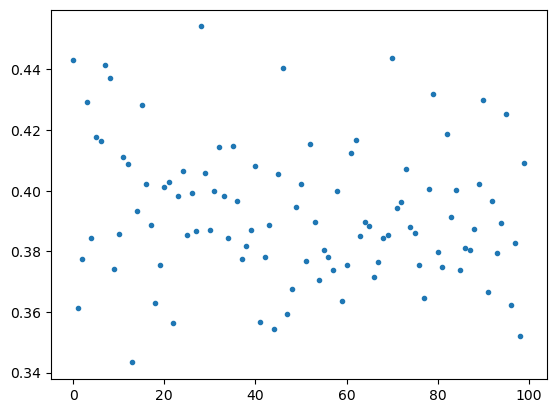

In [37]:
plt.plot(rlosses,'.')

# One run GPU Code 

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch 

from torch.utils.data import TensorDataset,DataLoader
import torch.nn as nn
import torch.nn.functional as F


print(os.listdir('../data'))

trainpd=pd.read_csv('../data/DRIFT_DATA_TRAIN.csv')

bs = 64 # batch size

trainpd=trainpd.drop(['year','month','day','x_EASE','y_EASE','id_buoy'],axis=1) #unwanted quantities



# NORMALIZATION STEP
#for day of year, simply divide by 364 to get smth between 0 and 1 (order 1)
trainpd['doy']=trainpd['doy']/364

# for the speeds, we substract the mean and divide by the standard deviation to get some cleaner distribution
speeds=['u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5']

means={}
stds={}
for label in speeds:
    means[label]=trainpd[label].mean()
    stds[label]=trainpd[label].std()
    trainpd[label]=(trainpd[label]-trainpd[label].mean())/trainpd[label].std()


print(means)
print(stds)
# SIC is already [0,1] and sea ice thickness is typically between 0 and idk 5 nothing is needed



target = pd.DataFrame([trainpd['u_buoy'],trainpd['v_buoy']]).T# had to reshape from u,v x rows to rows x u,v

trainpd = trainpd.drop(['u_buoy', 'v_buoy'],axis=1) # Take away the time of the year, wrong dtype and seems to be useless anyway
labels = [target.columns, trainpd.columns]
# we keep the day of year tho

traintensor = torch.tensor(trainpd.values, dtype= torch.float32)
targetensor = torch.tensor(target.values, dtype= torch.float32) 
print(target.shape)
print(traintensor.shape)
baseline_mse = torch.mean(targetensor**2).item()  # predicting all-zeros
print("Baseline MSE (predict mean):", baseline_mse)
trainset=TensorDataset(targetensor,traintensor)
trainloader=DataLoader(trainset,batch_size=bs,shuffle=True)

# creating my neural network

class firstNN(nn.Module):
    """Hummmm"""
    def __init__(self, n_inputs):
        """256->128->64"""
        super().__init__()
        self.fc1=nn.Linear(n_inputs,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,64)
        # self.fc4=nn.Linear(32,16)
        # self.fc5=nn.Linear(16,8)
        # self.fc6=nn.Linear(8,4)
        self.final=nn.Linear(64,2)

    def forward(self,x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=F.relu(self.fc3(x))
        # x=F.sigmoid(self.fc4(x))
        # x=F.sigmoid(self.fc5(x))
        # x=F.sigmoid(self.fc6(x))
        x=self.final(x)
        return x
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

print(device)

babygpu= firstNN(n_inputs=traintensor.shape[1]).to(device)
print(babygpu.parameters)

# ALL RIGHT LETS TRY TO TRAIN THAT THING
import torch.optim as optim

# Hyperparameters
lr=0.001
epoch=20


optimizer = optim.Adam(babygpu.parameters(),lr=lr) # optimizers
criterion = nn.MSELoss()

def RMSE(target,outputs):
    '''Calculates the RMSE between, the target and the model outputs'''
    return (torch.mean((target-outputs)**2))**.5

rlosses=[]
losses=[]
rloss=0
rcount=0


for epoch in range(epoch):
    print('Epoch: ',epoch)
    curpercent=0
    for i,data in enumerate(trainloader):

        # get the inputs and the target
        truth,inputs= data[0].to(device),data[1].to(device)

        # zero the gradients,
        optimizer.zero_grad()

        # Forward,
        out=babygpu(inputs)


        loss = criterion(out,truth)
        # Backward
        loss.backward()
        losses.append(loss.item())
        # Optimize

        optimizer.step()

        rloss+= loss.item()
        rcount +=1
        #print where we at plus the loss
        percent= round(i/len(trainloader)*100)
        if percent != curpercent:
            print(percent, 'loss: ', rloss/rcount)
            curpercent=percent
            rlosses.append(rloss/rcount)
            rloss=0
            rcount=0

plt.plot(rlosses,'.')

plt.show()

# Variable Learning Rates

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch 

from torch.utils.data import TensorDataset,DataLoader
import torch.nn as nn
import torch.nn.functional as F


print(os.listdir('../data'))

trainpd=pd.read_csv('../data/DRIFT_DATA_TRAIN.csv')

bs = 64 # batch size

trainpd=trainpd.drop(['year','month','day','x_EASE','y_EASE','id_buoy'],axis=1) #unwanted quantities



# NORMALIZATION STEP
#for day of year, simply divide by 364 to get smth between 0 and 1 (order 1)
trainpd['doy']=trainpd['doy']/364

# for the speeds, we substract the mean and divide by the standard deviation to get some cleaner distribution
speeds=['u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5']

means={}
stds={}
for label in speeds:
    means[label]=trainpd[label].mean()
    stds[label]=trainpd[label].std()
    trainpd[label]=(trainpd[label]-trainpd[label].mean())/trainpd[label].std()


print(means)
print(stds)
# SIC is already [0,1] and sea ice thickness is typically between 0 and idk 5 nothing is needed



target = pd.DataFrame([trainpd['u_buoy'],trainpd['v_buoy']]).T# had to reshape from u,v x rows to rows x u,v

trainpd = trainpd.drop(['u_buoy', 'v_buoy'],axis=1) # Take away the time of the year, wrong dtype and seems to be useless anyway
labels = [target.columns, trainpd.columns]
# we keep the day of year tho

traintensor = torch.tensor(trainpd.values, dtype= torch.float32)
targetensor = torch.tensor(target.values, dtype= torch.float32) 
print(target.shape)
print(traintensor.shape)
baseline_mse = torch.mean(targetensor**2).item()  # predicting all-zeros
print("Baseline MSE (predict mean):", baseline_mse)
trainset=TensorDataset(targetensor,traintensor)
trainloader=DataLoader(trainset,batch_size=bs,shuffle=True)

# creating my neural network

class firstNN(nn.Module):
    """Hummmm"""
    def __init__(self, n_inputs):
        """MLP with Relu, 256->128->64
        linear 64->2"""
        super().__init__()
        self.fc1=nn.Linear(n_inputs,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,64)
        # self.fc4=nn.Linear(32,16)
        # self.fc5=nn.Linear(16,8)
        # self.fc6=nn.Linear(8,4)
        self.final=nn.Linear(64,2)
        #self.fourier=nn.Linear(n_inputs,n_inputs)

    def forward(self,x):
        #x=torch.cos(self.fourier(x))
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=F.relu(self.fc3(x))
        # x=F.sigmoid(self.fc4(x))
        # x=F.sigmoid(self.fc5(x))
        # x=F.sigmoid(self.fc6(x))
        x=self.final(x)
        return x


# Bring it to GPU
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

print(device)

babygpu= firstNN(n_inputs=traintensor.shape[1]).to(device)
print(babygpu.parameters)

# ALL RIGHT LETS TRY TO TRAIN THAT THING
import torch.optim as optim

# Hyperparameters
# lr=0.001

epoch=20
lr= np.linspace(0.001, 0.00001, epoch)
print(lr)

criterion = nn.MSELoss()

def RMSE(target,outputs):
    '''Calculates the RMSE between, the target and the model outputs'''
    return (torch.mean((target-outputs)**2))**.5

rlosses={}
losses=[]

rloss=0
rcount=0
#learningrates=[]

for epoch in range(epoch):
    print('Epoch: ',epoch)
    print('Learning Rate: ', lr[epoch])
    curpercent=0
    rl=[]

    optimizer = optim.Adam(babygpu.parameters(),lr=lr[epoch]) # optimizers

    for i,data in enumerate(trainloader):

        # get the inputs and the target
        truth,inputs= data[0].to(device),data[1].to(device)

        # zero the gradients,
        optimizer.zero_grad()

        # Forward,
        out=babygpu(inputs)


        loss = criterion(out,truth)
        # Backward
        loss.backward()
        losses.append(loss.item())
        # Optimize

        optimizer.step()

        rloss+= loss.item()
        rcount +=1
        #print where we at plus the loss
        percent= round(i/len(trainloader)*100)
        if percent != curpercent:
        #    print(percent, 'loss: ', rloss/rcount)
            curpercent=percent
            rl.append(rloss/rcount)
            rloss=0
            rcount=0
    rlosses[epoch]=rl
    # learningrates.append(lr)
    # lr*=.75


['bathymetry_EASE.csv', 'DRIFT_DATA_FULL.csv', 'DRIFT_DATA_FULL_hackathon.csv', 'DRIFT_DATA_TEST.csv', 'DRIFT_DATA_TEST_ans.csv', 'DRIFT_DATA_TRAIN.csv', 'latitude_EASE.csv', 'longitude_EASE.csv', 'README.txt']
{'u_buoy': np.float64(-0.32911380120878647), 'v_buoy': np.float64(1.3688631602290797), 'u_ERA5': np.float64(-0.09414265660210988), 'v_ERA5': np.float64(0.34181398888012804)}
{'u_buoy': 8.060844323805954, 'v_buoy': 7.8546459505739765, 'u_ERA5': 4.31685881983416, 'v_ERA5': 4.122204959702637}
(339156, 2)
torch.Size([339156, 5])
Baseline MSE (predict mean): 0.999997079372406
cuda
<bound method Module.parameters of firstNN(
  (fc1): Linear(in_features=5, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (final): Linear(in_features=64, out_features=2, bias=True)
  (fourier): Linear(in_features=5, out_features=5, bias=True)
)>
[1.00000000e-03 9.47894737e-04 8.95789474e-04 8.43684211e

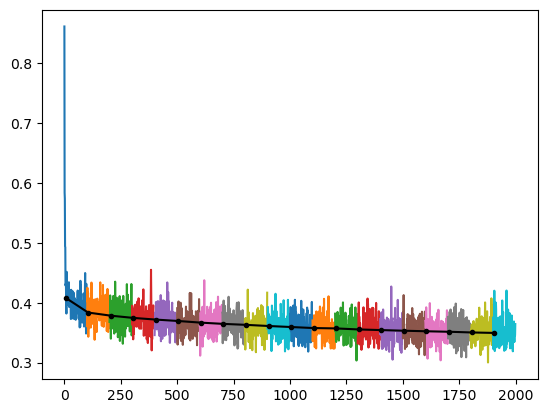

[np.float64(0.40840177086325036), np.float64(0.38366583123521986), np.float64(0.3784592353594752), np.float64(0.3747215913517295), np.float64(0.37190537926442213), np.float64(0.36953772385305955), np.float64(0.36680648513278874), np.float64(0.36472293291451796), np.float64(0.36312056779580293), np.float64(0.3611876418441534), np.float64(0.35948692337521976), np.float64(0.357768107323714), np.float64(0.35715429345532407), np.float64(0.3554224347281005), np.float64(0.3543648432616917), np.float64(0.3533139879846911), np.float64(0.3523932957888212), np.float64(0.35157600583332893), np.float64(0.35041624297651475), np.float64(0.3496386035798856)]
[1.00000000e-03 9.47894737e-04 8.95789474e-04 8.43684211e-04
 7.91578947e-04 7.39473684e-04 6.87368421e-04 6.35263158e-04
 5.83157895e-04 5.31052632e-04 4.78947368e-04 4.26842105e-04
 3.74736842e-04 3.22631579e-04 2.70526316e-04 2.18421053e-04
 1.66315789e-04 1.14210526e-04 6.21052632e-05 1.00000000e-05]


In [209]:
fig,ax =plt.subplots()
epochavg=[]

for i in (rlosses):
    x=np.arange(i*100,100+i*100)
    ax.plot(x,rlosses[i],label=f'Epoch {i+1}, lr={lr[i]:.1e}')
    avg=np.mean(rlosses[i])
    epochavg.append(avg)

xx=[i*100+5 for i in rlosses]
ax.plot(xx,epochavg,'.-k')
#fig.legend()
plt.xlim([])

plt.show()

print(epochavg)
print(lr)

# Adding the cos and sin of the year

['bathymetry_EASE.csv', 'DRIFT_DATA_FULL.csv', 'DRIFT_DATA_FULL_hackathon.csv', 'DRIFT_DATA_TEST.csv', 'DRIFT_DATA_TEST_ans.csv', 'DRIFT_DATA_TRAIN.csv', 'latitude_EASE.csv', 'longitude_EASE.csv', 'README.txt']
{'u_buoy': np.float64(-0.32911380120878647), 'v_buoy': np.float64(1.3688631602290797), 'u_ERA5': np.float64(-0.09414265660210988), 'v_ERA5': np.float64(0.34181398888012804)}
{'u_buoy': 8.060844323805954, 'v_buoy': 7.8546459505739765, 'u_ERA5': 4.31685881983416, 'v_ERA5': 4.122204959702637}
(339156, 2)
torch.Size([339156, 6])
Baseline MSE (predict mean): 0.999997079372406
cuda
6
<bound method Module.parameters of firstNN(
  (fc1): Linear(in_features=6, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (final): Linear(in_features=64, out_features=2, bias=True)
)>
(800,)
Starting Epoch  0
Learning Rate:  0.001
Epoch avg loss:  0.6320560619235038
Starting Epoch  1
Learning Rate:  

ValueError: x and y must have same first dimension, but have shapes (100,) and (20,)

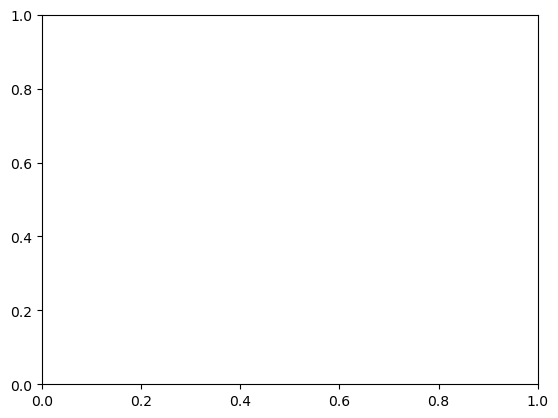

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch 

from torch.utils.data import TensorDataset,DataLoader
import torch.nn as nn
import torch.nn.functional as F


print(os.listdir('../data'))

trainpd=pd.read_csv('../data/DRIFT_DATA_TRAIN.csv')

bs = 2**13 # batch size

trainpd=trainpd.drop(['year','month','day','x_EASE','y_EASE','id_buoy'],axis=1) #unwanted quantities

#ADDING THE COS AND SIN OF THE YEAR
trainpd['sin']=np.sin(trainpd['doy']*(2*np.pi/364))
trainpd['cos']=np.cos(trainpd['doy']*(2*np.pi/364))

#dropping the day of year
trainpd=trainpd.drop(['doy'],axis =1 )

# NORMALIZATION STEP

# for the speeds, we substract the mean and divide by the standard deviation to get some cleaner distribution
speeds=['u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5']

means={}
stds={}
for label in speeds:
    means[label]=trainpd[label].mean()
    stds[label]=trainpd[label].std()
    trainpd[label]=(trainpd[label]-trainpd[label].mean())/trainpd[label].std()


print(means)
print(stds)
# SIC is already [0,1] and sea ice thickness is typically between 0 and idk 5 nothing is needed



target = pd.DataFrame([trainpd['u_buoy'],trainpd['v_buoy']]).T# had to reshape from u,v x rows to rows x u,v

trainpd = trainpd.drop(['u_buoy', 'v_buoy'],axis=1) # Take away the time of the year, wrong dtype and seems to be useless anyway
labels = [target.columns, trainpd.columns]
# we keep the day of year tho

traintensor = torch.tensor(trainpd.values, dtype= torch.float32)
targetensor = torch.tensor(target.values, dtype= torch.float32) 
print(target.shape)
print(traintensor.shape)
baseline_mse = torch.mean(targetensor**2).item()  # predicting all-zeros
print("Baseline MSE (predict mean):", baseline_mse)
trainset=TensorDataset(targetensor,traintensor)
trainloader=DataLoader(trainset,batch_size=bs,shuffle=True)

# creating my neural network

class firstNN(nn.Module):
    """Hummmm"""
    def __init__(self, n_inputs):
        """MLP with Relu, 256->128->64
        linear 64->2"""
        super().__init__()
        self.fc1=nn.Linear(n_inputs,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,64)
        # self.fc4=nn.Linear(32,16)
        # self.fc5=nn.Linear(16,8)
        # self.fc6=nn.Linear(8,4)
        self.final=nn.Linear(64,2)
        #self.fourier=nn.Linear(n_inputs,n_inputs)

    def forward(self,x):
        #x=torch.cos(self.fourier(x))
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=F.relu(self.fc3(x))
        # x=F.sigmoid(self.fc4(x))
        # x=F.sigmoid(self.fc5(x))
        # x=F.sigmoid(self.fc6(x))
        x=self.final(x)
        return x


# Bring it to GPU
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

print(device)

print(traintensor.shape[1])
babygpu= firstNN(n_inputs=traintensor.shape[1]).to(device)
print(babygpu.parameters)

# ALL RIGHT LETS TRY TO TRAIN THAT THING
import torch.optim as optim

# Hyperparameters
# lr=0.001

epoch=800
lr= np.linspace(1e-3, 5e-6, epoch)
# l=np.full_like(lr,0.00001)
# lr=np.hstack((lr,l))


print(lr.shape)

criterion = nn.MSELoss()

def RMSE(target,outputs):
    '''Calculates the RMSE between, the target and the model outputs'''
    return (torch.mean((target-outputs)**2))**.5

rlosses={}
losses=[]

rloss=0
rcount=0
#learningrates=[]

for epoch in range(epoch):
    print('Starting Epoch ',epoch)
    print('Learning Rate: ', lr[epoch])
    curpercent=0
    rl=[]

    optimizer = optim.Adam(babygpu.parameters(),lr=lr[epoch]) # optimizers

    for i,data in enumerate(trainloader):

        # get the inputs and the target
        truth,inputs= data[0].to(device),data[1].to(device)

        # zero the gradients,
        optimizer.zero_grad()

        # Forward,
        out=babygpu(inputs)


        loss = criterion(out,truth)
        # Backward
        loss.backward()
        losses.append(loss.item())
        # Optimize

        optimizer.step()

        rloss+= loss.item()
        rcount +=1
        #print where we at plus the loss
        percent= round(i/len(trainloader)*100)
        if percent != curpercent:
        #    print(percent, 'loss: ', rloss/rcount)
            curpercent=percent
            rl.append(rloss/rcount)
            rloss=0
            rcount=0
    rlosses[epoch]=rl
    print('Epoch avg loss: ', np.mean(rl))
    # learningrates.append(lr)
    # lr*=.75
fig,ax =plt.subplots()
epochavg=[]

for i in (rlosses):
    x=np.arange(i*100,100+i*100)
    ax.plot(x,rlosses[i],label=f'Epoch {i+1}, lr={lr[i]:.1e}')
    avg=np.mean(rlosses[i])
    epochavg.append(avg)

xx=[i*100+5 for i in rlosses]
ax.plot(xx,epochavg,'.-k')
#fig.legend()

plt.show()



20


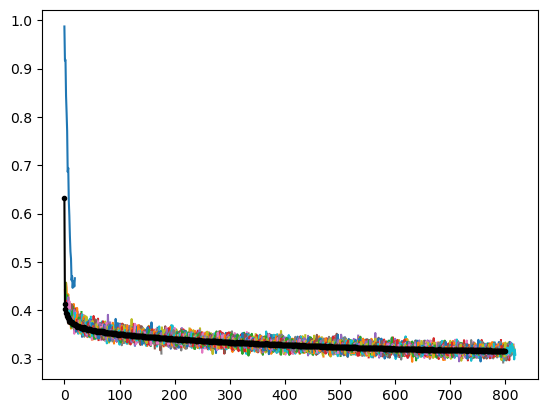

In [299]:
print(len(rlosses[2]))
fig,ax =plt.subplots()
epochavg=[]

for i in (rlosses):
    x=np.arange(i, len(rlosses[0])+i)
    ax.plot(x,rlosses[i],label=f'Epoch {i+1}, lr={lr[i]:.1e}')
    avg=np.mean(rlosses[i])
    epochavg.append(avg)

xx=[i for i in rlosses]
ax.plot(xx,epochavg,'.-k')
#fig.legend()

plt.show()

In [279]:
print(eepocavg[-1])
print(epochavg[-1])
xx=[i*100+5 for i in rlosses]
plt.plot(xx,epochavg,'.-k')

der=[]
for i in range(149):
    der.append(epochavg[i+50]-epochavg[i+51])

print(np.mean(der))
print(.2/np.mean(der))

0.31422227047383783


IndexError: list index out of range

# Trying to predict just the norms

In [330]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch 

from torch.utils.data import TensorDataset,DataLoader
import torch.nn as nn
import torch.nn.functional as F

#########################################################################################################################################33

trainpd=pd.read_csv('../data/DRIFT_DATA_TRAIN.csv')

bs = 2**13 # batch size

trainpd=trainpd.drop(['year','month','day','x_EASE','y_EASE','id_buoy'],axis=1) #unwanted quantities

#ADDING THE COS AND SIN OF THE YEAR
trainpd['sin']=np.sin(trainpd['doy']*(2*np.pi/364))
trainpd['cos']=np.cos(trainpd['doy']*(2*np.pi/364))

#dropping the day of year
trainpd=trainpd.drop(['doy'],axis =1 )

# adding the norms

trainpd['windnorm']=np.sqrt(trainpd['u_ERA5']**2+trainpd['v_ERA5']**2)
trainpd['buoynorm']=np.sqrt(trainpd['u_buoy']**2+trainpd['v_buoy']**2)
# NORMALIZATION STEP

# for the speeds, we substract the mean and divide by the standard deviation to get some cleaner distribution
speeds=['u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5', 'windnorm','buoynorm']

means={}
stds={}
for label in speeds:
    means[label]=trainpd[label].mean()
    stds[label]=trainpd[label].std()
    trainpd[label]=(trainpd[label]-trainpd[label].mean())/trainpd[label].std()


print(means)
print(stds)
# SIC is already [0,1] and sea ice thickness is typically between 0 and idk 5 nothing is needed




target = pd.DataFrame(trainpd['buoynorm'])# 

trainpd = trainpd.drop(['u_buoy', 'v_buoy','buoynorm'],axis=1) # Take away the time of the year, wrong dtype and seems to be useless anyway
labels = [target.columns, trainpd.columns]
# we keep the day of year tho



traintensor = torch.tensor(trainpd.values, dtype= torch.float32)
targetensor = torch.tensor(target.values, dtype= torch.float32) 

print('Labels: ', labels)

baseline_mse = torch.mean(targetensor**2).item()  # predicting all-zeros
print("Baseline MSE (predict mean):", baseline_mse)

# Building the dataset and loader
trainset=TensorDataset(targetensor,traintensor)
trainloader=DataLoader(trainset,batch_size=bs,shuffle=True)


####################################################################################################################################################
# creating my neural network

class firstNN(nn.Module):
    """Hummmm"""
    def __init__(self, n_inputs):
        """MLP with Relu, 256->128->64
        linear 64->2"""
        super().__init__()
        self.fc1=nn.Linear(n_inputs,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,64)
        # self.fc4=nn.Linear(32,16)
        # self.fc5=nn.Linear(16,8)
        # self.fc6=nn.Linear(8,4)
        self.final=nn.Linear(64,1)
        #self.fourier=nn.Linear(n_inputs,n_inputs)

    def forward(self,x):
        #x=torch.cos(self.fourier(x))
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=F.relu(self.fc3(x))
        # x=F.sigmoid(self.fc4(x))
        # x=F.sigmoid(self.fc5(x))
        # x=F.sigmoid(self.fc6(x))
        x=self.final(x)
        return x


# Bring it to GPU
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

print(device)

print(traintensor.shape[1])
babygpu= firstNN(n_inputs=traintensor.shape[1]).to(device)
print(babygpu.parameters)


###########################################################################################################################################################3
# ALL RIGHT LETS TRY TO TRAIN THAT THING
import torch.optim as optim

# Hyperparameters
# lr=0.001

epoch=600
lr_start=1e-3
lr_end=1e-5
lr= np.linspace(lr_start, lr_end, epoch)
# l=np.full_like(lr,0.00001)
# lr=np.hstack((lr,l))

print('Total Epoch: ', epoch)
print(f'Linear decrease in learning rate from {lr_start} to {lr_end}')


criterion = nn.MSELoss()

def RMSE(target,outputs):
    '''Calculates the RMSE between, the target and the model outputs'''
    return (torch.mean((target-outputs)**2))**.5

rlosses={}
losses=[]

rloss=0
rcount=0
#learningrates=[]

for epoch in range(epoch):
    print('Starting Epoch ',epoch)
    print('Learning Rate: ', lr[epoch])
    curpercent=0
    rl=[]

    optimizer = optim.Adam(babygpu.parameters(),lr=lr[epoch]) # optimizers

    for i,data in enumerate(trainloader):

        # get the inputs and the target
        truth,inputs= data[0].to(device),data[1].to(device)

        # zero the gradients,
        optimizer.zero_grad()

        # Forward,
        out=babygpu(inputs)


        loss = criterion(out,truth)
        # Backward
        loss.backward()
        losses.append(loss.item())
        # Optimize

        optimizer.step()

        rloss+= loss.item()
        rcount +=1
        #print where we at plus the loss
        percent= round(i/len(trainloader)*100)
        if percent != curpercent:
        #    print(percent, 'loss: ', rloss/rcount)
            curpercent=percent
            rl.append(rloss/rcount)
            rloss=0
            rcount=0
    rlosses[epoch]=rl
    print('Epoch avg loss: ', np.mean(rl))
    # learningrates.append(lr)
    # lr*=.75

torch.save(babygpu.state_dict(), f'.//weights//babygpu_{epoch}E_{lr_start}LR{lr_end}_{labels[0].item()}.pt')



{'u_buoy': np.float64(-0.32911380120878647), 'v_buoy': np.float64(1.3688631602290797), 'u_ERA5': np.float64(-0.09414265660210988), 'v_ERA5': np.float64(0.34181398888012804), 'windnorm': np.float64(5.35318035300248), 'buoynorm': np.float64(8.347371797306305)}
{'u_buoy': 8.060844323805954, 'v_buoy': 7.8546459505739765, 'u_ERA5': 4.31685881983416, 'v_ERA5': 4.122204959702637, 'windnorm': 2.664004397121848, 'buoynorm': 7.67958077899918}
Labels:  [Index(['buoynorm'], dtype='object'), Index(['u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas', 'sin', 'cos', 'windnorm'], dtype='object')]
Baseline MSE (predict mean): 0.999997079372406
cuda
7
<bound method Module.parameters of firstNN(
  (fc1): Linear(in_features=7, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (final): Linear(in_features=64, out_features=1, bias=True)
)>
Total Epoch:  600
Linear decrease in learning rate from 0.001 to 1e-05
Starti

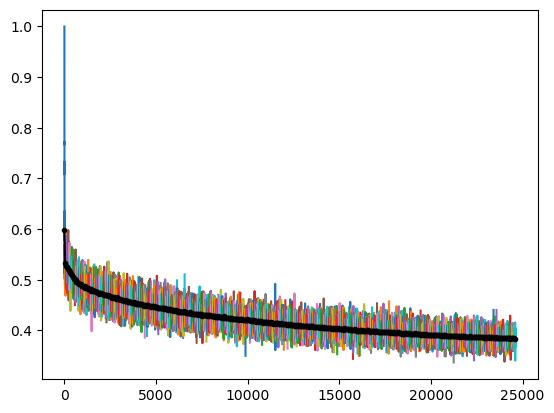

In [332]:
fig,ax =plt.subplots()
epochavg=[]

for i in (rlosses):
    x=np.arange(i*len(rlosses[0]),len(rlosses[0])+i*len(rlosses[0]))
    ax.plot(x,rlosses[i],label=f'Epoch {i+1}, lr={lr[i]:.1e}')
    avg=np.mean(rlosses[i])
    epochavg.append(avg)

xx=[i*len(rlosses[0]) for i in rlosses]
ax.plot(xx,epochavg,'.-k')
#fig.legend()
#plt.xlim([15000,20000])
plt.show()

# Norm + x,y EASE grid

{'u_buoy': np.float64(-0.32911380120878647), 'v_buoy': np.float64(1.3688631602290797), 'u_ERA5': np.float64(-0.09414265660210988), 'v_ERA5': np.float64(0.34181398888012804), 'windnorm': np.float64(5.35318035300248), 'buoynorm': np.float64(8.347371797306305)}
{'u_buoy': np.float64(8.060844323807583), 'v_buoy': np.float64(7.854645950573008), 'u_ERA5': np.float64(4.316858819834159), 'v_ERA5': np.float64(4.122204959702669), 'windnorm': np.float64(2.6640043971218503), 'buoynorm': np.float64(7.679580778998366)}
Labels:  [Index(['buoynorm'], dtype='str'), Index(['x_EASE', 'y_EASE', 'u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas', 'sin',
       'cos', 'windnorm', 'bath'],
      dtype='str')]
Baseline MSE (predict mean): 0.999997079372406
cuda
10
<bound method Module.parameters of firstNN(
  (fc1): Linear(in_features=10, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (final): Linear(in_features=

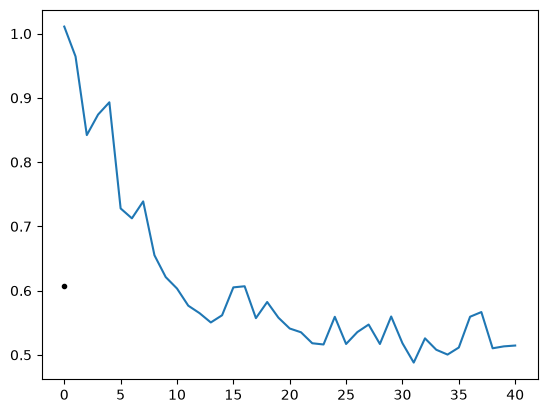

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch 

from torch.utils.data import TensorDataset,DataLoader
import torch.nn as nn
import torch.nn.functional as F

#########################################################################################################################################33

trainpd=pd.read_csv('../data/DRIFT_DATA_TRAIN.csv')

bs = 2**13 # batch size

trainpd=trainpd.drop(['year','month','day','id_buoy'],axis=1) #unwanted quantities

#ADDING THE COS AND SIN OF THE YEAR
trainpd['sin']=np.sin(trainpd['doy']*(2*np.pi/364))
trainpd['cos']=np.cos(trainpd['doy']*(2*np.pi/364))

#dropping the day of year
trainpd=trainpd.drop(['doy'],axis =1 )

# adding the norms

trainpd['windnorm']=np.sqrt(trainpd['u_ERA5']**2+trainpd['v_ERA5']**2)
trainpd['buoynorm']=np.sqrt(trainpd['u_buoy']**2+trainpd['v_buoy']**2)

# Adding the bathymetry
bath= pd.read_csv('../data/bathymetry_EASE.csv').values
trainpd['bath']= bath[trainpd['y_EASE'].astype(int),trainpd['x_EASE'].astype(int)]

# NORMALIZATION STEP

# for the speeds, we substract the mean and divide by the standard deviation to get some cleaner distribution
speeds=['u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5', 'windnorm','buoynorm']

means={}
stds={}
for label in speeds:
    means[label]=trainpd[label].mean()
    stds[label]=trainpd[label].std()
    trainpd[label]=(trainpd[label]-trainpd[label].mean())/trainpd[label].std()


print(means)
print(stds)
# SIC is already [0,1] and sea ice thickness is typically between 0 and idk 5 nothing is needed

# For the x,y, we simply divide by the max?
max_x=np.max(np.abs(trainpd['x_EASE']))
trainpd['x_EASE']=trainpd['x_EASE']/max_x

max_y =np.max(np.abs(trainpd['y_EASE']))
trainpd['y_EASE']=trainpd['y_EASE']/max_y

#For the Bathymetry we divide by the max as well (is actually a min)

max_bathy=np.max(np.abs(trainpd['bath']))
trainpd['bath']=trainpd['bath']/max_bathy


target = pd.DataFrame(trainpd['buoynorm'])# 

trainpd = trainpd.drop(['u_buoy', 'v_buoy','buoynorm'],axis=1) # Take away the time of the year, wrong dtype and seems to be useless anyway
labels = [target.columns, trainpd.columns]
# we keep the day of year tho



traintensor = torch.tensor(trainpd.values, dtype= torch.float32)
targetensor = torch.tensor(target.values, dtype= torch.float32) 

print('Labels: ', labels)

baseline_mse = torch.mean(targetensor**2).item()  # predicting all-zeros
print("Baseline MSE (predict mean):", baseline_mse)

# Building the dataset and loader
trainset=TensorDataset(targetensor,traintensor)
trainloader=DataLoader(trainset,batch_size=bs,shuffle=True)


####################################################################################################################################################
# creating my neural network

class firstNN(nn.Module):
    """Hummmm"""
    def __init__(self, n_inputs):
        """MLP with Relu, 256->128->64
        linear 64->2"""
        super().__init__()
        self.fc1=nn.Linear(n_inputs,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,64)
        # self.fc4=nn.Linear(32,16)
        # self.fc5=nn.Linear(16,8)
        # self.fc6=nn.Linear(8,4)
        self.final=nn.Linear(64,1)
        #self.fourier=nn.Linear(n_inputs,n_inputs)

    def forward(self,x):
        #x=torch.cos(self.fourier(x))
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=F.relu(self.fc3(x))
        # x=F.sigmoid(self.fc4(x))
        # x=F.sigmoid(self.fc5(x))
        # x=F.sigmoid(self.fc6(x))
        x=self.final(x)
        return x


# Bring it to GPU
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

print(device)

print(traintensor.shape[1])
babygpu= firstNN(n_inputs=traintensor.shape[1]).to(device)
print(babygpu.parameters)


###########################################################################################################################################################3
# ALL RIGHT LETS TRY TO TRAIN THAT THING
import torch.optim as optim

# Hyperparameters
# lr=0.001

epoch=1
lr_start=1e-3
lr_end=1e-5
lr= np.linspace(lr_start, lr_end, epoch)
# l=np.full_like(lr,0.00001)
# lr=np.hstack((lr,l))

print('Total Epoch: ', epoch)
print(f'Linear decrease in learning rate from {lr_start} to {lr_end}')


criterion = nn.MSELoss()

def RMSE(target,outputs):
    '''Calculates the RMSE between, the target and the model outputs'''
    return (torch.mean((target-outputs)**2))**.5

rlosses={}
losses=[]

rloss=0
rcount=0
#learningrates=[]

for epoch in range(epoch):
    print('Starting Epoch ',epoch)
    print('Learning Rate: ', lr[epoch])
    curpercent=0
    rl=[]

    optimizer = optim.Adam(babygpu.parameters(),lr=lr[epoch]) # optimizers

    for i,data in enumerate(trainloader):

        # get the inputs and the target
        truth,inputs= data[0].to(device),data[1].to(device)

        # zero the gradients,
        optimizer.zero_grad()

        # Forward,
        out=babygpu(inputs)


        loss = criterion(out,truth)
        # Backward
        loss.backward()
        losses.append(loss.item())
        # Optimize

        optimizer.step()

        rloss+= loss.item()
        rcount +=1
        #print where we at plus the loss
        percent= round(i/len(trainloader)*100)
        if percent != curpercent:
        #    print(percent, 'loss: ', rloss/rcount)
            curpercent=percent
            rl.append(rloss/rcount)
            rloss=0
            rcount=0
    rlosses[epoch]=rl
    print('Epoch avg loss: ', np.mean(rl))
    # learningrates.append(lr)
    # lr*=.75

torch.save(babygpu.state_dict(), f'.//weights//babygpu_{epoch}E_{lr_start}LR{lr_end}_{labels[0].item()}_XYEASE.pt')

fig,ax =plt.subplots()
epochavg=[]

for i in (rlosses):
    x=np.arange(i*len(rlosses[0]),len(rlosses[0])+i*len(rlosses[0]))
    ax.plot(x,rlosses[i],label=f'Epoch {i+1}, lr={lr[i]:.1e}')
    avg=np.mean(rlosses[i])
    epochavg.append(avg)

xx=[i*len(rlosses[0]) for i in rlosses]
ax.plot(xx,epochavg,'.-k')
#fig.legend()
#plt.xlim([15000,20000])
plt.savefig(f'.//outputs//babygpu_{epoch}E_{lr_start}LR{lr_end}_{labels[0].item()}_XYEASE.png')


# Getting the angle using the same input dataset as above


In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch 

from torch.utils.data import TensorDataset,DataLoader
import torch.nn as nn
import torch.nn.functional as F

#########################################################################################################################################33

trainpd=pd.read_csv('../data/DRIFT_DATA_TRAIN.csv')

bs = 2**13 # batch size

trainpd=trainpd.drop(['year','month','day','id_buoy'],axis=1) #unwanted quantities

#ADDING THE COS AND SIN OF THE YEAR
trainpd['sin']=np.sin(trainpd['doy']*(2*np.pi/364))
trainpd['cos']=np.cos(trainpd['doy']*(2*np.pi/364))

#dropping the day of year
trainpd=trainpd.drop(['doy'],axis =1 )

# adding the norms

trainpd['windnorm']=np.sqrt(trainpd['u_ERA5']**2+trainpd['v_ERA5']**2)
# NORMALIZATION STEP

# for the speeds, we substract the mean and divide by the standard deviation to get some cleaner distribution
speeds=['u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5', 'windnorm']

means={}
stds={}
for label in speeds:
    means[label]=trainpd[label].mean()
    stds[label]=trainpd[label].std()
    trainpd[label]=(trainpd[label]-trainpd[label].mean())/trainpd[label].std()


print(means)
print(stds)
# SIC is already [0,1] and sea ice thickness is typically between 0 and idk 5 nothing is needed

# For the x,y, we simply divide by the max?
max_x=np.max(np.abs(trainpd['x_EASE']))
trainpd['x_EASE']=trainpd['x_EASE']/max_x

max_y =np.max(np.abs(trainpd['y_EASE']))
trainpd['y_EASE']=trainpd['y_EASE']/max_y



target = pd.DataFrame(trainpd['buoynorm'])# 

trainpd = trainpd.drop(['u_buoy', 'v_buoy','buoynorm'],axis=1) # Take away the time of the year, wrong dtype and seems to be useless anyway
labels = [target.columns, trainpd.columns]
# we keep the day of year tho



traintensor = torch.tensor(trainpd.values, dtype= torch.float32)
targetensor = torch.tensor(target.values, dtype= torch.float32) 

print('Labels: ', labels)

baseline_mse = torch.mean(targetensor**2).item()  # predicting all-zeros
print("Baseline MSE (predict mean):", baseline_mse)

# Building the dataset and loader
trainset=TensorDataset(targetensor,traintensor)
trainloader=DataLoader(trainset,batch_size=bs,shuffle=True)


####################################################################################################################################################
# creating my neural network

class firstNN(nn.Module):
    """Hummmm"""
    def __init__(self, n_inputs):
        """MLP with Relu, 256->128->64
        linear 64->2"""
        super().__init__()
        self.fc1=nn.Linear(n_inputs,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,64)
        # self.fc4=nn.Linear(32,16)
        # self.fc5=nn.Linear(16,8)
        # self.fc6=nn.Linear(8,4)
        self.final=nn.Linear(64,1)
        #self.fourier=nn.Linear(n_inputs,n_inputs)

    def forward(self,x):
        #x=torch.cos(self.fourier(x))
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=F.relu(self.fc3(x))
        # x=F.sigmoid(self.fc4(x))
        # x=F.sigmoid(self.fc5(x))
        # x=F.sigmoid(self.fc6(x))
        x=self.final(x)
        return x


# Bring it to GPU
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

print(device)

print(traintensor.shape[1])
babygpu= firstNN(n_inputs=traintensor.shape[1]).to(device)
print(babygpu.parameters)


###########################################################################################################################################################3
# ALL RIGHT LETS TRY TO TRAIN THAT THING
import torch.optim as optim

# Hyperparameters
# lr=0.001

epoch=1
lr_start=1e-3
lr_end=1e-5
lr= np.linspace(lr_start, lr_end, epoch)
# l=np.full_like(lr,0.00001)
# lr=np.hstack((lr,l))

print('Total Epoch: ', epoch)
print(f'Linear decrease in learning rate from {lr_start} to {lr_end}')


criterion = nn.MSELoss()

def RMSE(target,outputs):
    '''Calculates the RMSE between, the target and the model outputs'''
    return (torch.mean((target-outputs)**2))**.5

rlosses={}
losses=[]

rloss=0
rcount=0
#learningrates=[]

for epoch in range(epoch):
    print('Starting Epoch ',epoch)
    print('Learning Rate: ', lr[epoch])
    curpercent=0
    rl=[]

    optimizer = optim.Adam(babygpu.parameters(),lr=lr[epoch]) # optimizers

    for i,data in enumerate(trainloader):

        # get the inputs and the target
        truth,inputs= data[0].to(device),data[1].to(device)

        # zero the gradients,
        optimizer.zero_grad()

        # Forward,
        out=babygpu(inputs)


        loss = criterion(out,truth)
        # Backward
        loss.backward()
        losses.append(loss.item())
        # Optimize

        optimizer.step()

        rloss+= loss.item()
        rcount +=1
        #print where we at plus the loss
        percent= round(i/len(trainloader)*100)
        if percent != curpercent:
        #    print(percent, 'loss: ', rloss/rcount)
            curpercent=percent
            rl.append(rloss/rcount)
            rloss=0
            rcount=0
    rlosses[epoch]=rl
    print('Epoch avg loss: ', np.mean(rl))
    # learningrates.append(lr)
    # lr*=.75

torch.save(babygpu.state_dict(), f'.//weights//babygpu_{epoch}E_{lr_start}LR{lr_end}_{labels[0].item()}_XYEASE.pt')

fig,ax =plt.subplots()
epochavg=[]

for i in (rlosses):
    x=np.arange(i*len(rlosses[0]),len(rlosses[0])+i*len(rlosses[0]))
    ax.plot(x,rlosses[i],label=f'Epoch {i+1}, lr={lr[i]:.1e}')
    avg=np.mean(rlosses[i])
    epochavg.append(avg)

xx=[i*len(rlosses[0]) for i in rlosses]
ax.plot(xx,epochavg,'.-k')
#fig.legend()
#plt.xlim([15000,20000])
plt.savefig(f'.//outputs//babygpu_{epoch}E_{lr_start}LR{lr_end}_{labels[0].item()}_XYEASE.png')


# Validating against the TEST dataset

for the sin/cos case

200 epoch with linear 1e3 to 1e5:  rmse 6.591
20 epoch: 6.63
800 with linear 1e3 to 1e7 (too low): rmse 6.602

[600 norm](weights/babygpu_599E_0.001LR1e-05_buoynorm.pt): 5.24

In [370]:
testpd = pd.read_csv('../data/DRIFT_DATA_TEST.csv')
print(len(testpd))
target_bs=84789#2048 84789



#taking away the unwanted

testpd=testpd.drop(['year','month','day','x_EASE','y_EASE','id_buoy'],axis=1)

#ADDING THE COS AND SIN OF THE YEAR
testpd['sin']=np.sin(testpd['doy']*(2*np.pi/364))
testpd['cos']=np.cos(testpd['doy']*(2*np.pi/364))

#dropping the day of year
testpd=testpd.drop(['doy'],axis =1 )

# NORMALIZATION STEP

#for day of year, simply divide by 364 to get smth between 0 and 1 (order 1)
#testpd['doy']=testpd['doy']/364

# for the speeds, we substract the mean and divide by the standard deviation to get some cleaner distribution
speeds=['u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5']

testmeans={}
teststds={}
for label in speeds:
    testmeans[label]=testpd[label].mean()
    teststds[label]=testpd[label].std()
    testpd[label]=(testpd[label]-testpd[label].mean())/testpd[label].std()

testtarget = pd.DataFrame([testpd['u_buoy'],testpd['v_buoy']]).T# had to reshape from u,v x rows to rows x u,v

testpd = testpd.drop(['u_buoy', 'v_buoy'],axis=1) # Take away the time of the year, wrong dtype and seems to be useless anyway
testlabels = [testtarget.columns, testpd.columns]


testtensor = torch.tensor(testpd.values, dtype= torch.float32)
targetensor = torch.tensor(testtarget.values, dtype= torch.float32) 

testset=TensorDataset(targetensor,testtensor)
testloader=DataLoader(testset,batch_size=target_bs,shuffle=True)
print(testlabels)

84789
[Index(['u_buoy', 'v_buoy'], dtype='object'), Index(['u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas', 'sin', 'cos'], dtype='object')]


In [371]:
###############################################################################################################################


testsample=next(iter(testloader))
#print(testsample)
testout=babygpu(testsample[1].to(device)).to('cpu')

def L2norm(u,v):
    return (u**2+v**2)**.5


# Redimensionalize
dimout=[]
dimsample=[]
wind=[]
doy=[]
norms=[]
h=[]
sic=[]


for k,i in enumerate(testout):
   #ice speeds
    udimout= i[0].item()*stds['u_buoy']+means['u_buoy']
    vdimout= i[1].item()*stds['v_buoy']+means['v_buoy']
    dimout.append([udimout,vdimout])
    #TARGET SPEEDs
    udimtarget= testsample[0][k][0].item()*teststds['u_buoy']+testmeans['u_buoy']
    vdimtarget= testsample[0][k][1].item()*teststds['v_buoy']+testmeans['v_buoy']
    dimsample.append([udimtarget,vdimtarget])
    #INPUT PARAMETERS
    # #wind speeds
    # uera=testsample[1][k][1].item()*teststds['u_ERA5']+testmeans['u_ERA5']
    # vera=testsample[1][k][2].item()*teststds['v_ERA5']+testmeans['v_ERA5']
    # wind.append([uera,vera])
    # # doy
    # doy.append(testsample[1][k][0]*364)
    # #norms
    # norms.append([L2norm(udimtarget,vdimtarget), L2norm(udimout,vdimout), L2norm(uera,vera)])
    # #thickness
    # h.append(testsample[1][k][-1])
    # #concentration
    # sic.append(testsample[1][k][3])

    #wind speeds
    uera=testsample[1][k][0].item()*teststds['u_ERA5']+testmeans['u_ERA5']
    vera=testsample[1][k][1].item()*teststds['v_ERA5']+testmeans['v_ERA5']
    wind.append([uera,vera])
    # doy

    #norms
    norms.append([L2norm(udimtarget,vdimtarget), L2norm(udimout,vdimout), L2norm(uera,vera)])
    #thickness
    h.append(testsample[1][k][3])
    #concentration
    sic.append(testsample[1][k][2])

dimout=np.array(dimout)
dimsample=np.array(dimsample)
wind=np.array(wind)
#doy=np.array(doy)

sic=np.array(sic)
h=np.array(h)
norms=np.array(norms).T
print(norms[0].shape)

data= {
    'OutputVel': dimout,
    'TargetVel': dimsample,
    'WindEra5': wind,
   # 'Day of Year': doy,
    'SIC':sic,
    'h':h,
    'TargetNorm':norms[0],
    'OutputNorm':norms[1],
    'WindNorm': norms[2],

}


# print('1st Target Velocites: ', f'{labels[0].values}\n {dimsample[0]}')
# # print('1st Input variables: ', labels[1].values)
# # print(testsample[1][0])
# print('outputted velocities', dimout[0])
# rmse=[]
# vrmse=[]
# urmse=[]
# residuals=[]
# for i,m in enumerate(dimsample):
#     ures=m[0]-dimout[i][0]
#     vres=m[1]-dimout[i][1]
#     residuals.append([ures,vres])
#     rmse.append((ures**2+vres**2)**.5)
# residuals=np.array(residuals)
# rmse=np.array(rmse)
# print(residuals.T)
# print(rmse.shape)
# plt.hist(residuals.T[0])
# plt.show()
# plt.hist(residuals.T[1])
# # print(len(testout))
# for i in range(len(testout)):
#     utru=testsample[0][i][0]
#     vtru=testsample[0][i][1]

#     uout=testout[i][0]
#     vout=testout[i][1]
#     uerr=RMSE(utru,uout)
#     verr=RMSE(vtru,vout)
#     urmse.append(uerr)
#     vrmse.append(verr)
#     rmse.append((uerr**2+verr**2)**.5)
# print(urmse)

(84789,)


In [373]:
rmse=[]
for i in range(data['OutputVel'].shape[0]):
    uout,vout=data['OutputVel'][i][0],data['OutputVel'][i][1]
    u,v=data['TargetVel'][i][0],data['TargetVel'][i][1]
    rmse.append((uout-u)**2+(vout-v)**2)

mse=np.mean(rmse)
Rmse=np.sqrt(mse)

#Or vectorized

rMse=np.sqrt(np.mean(np.sum((data['OutputVel']-data['TargetVel'])**2, axis=1)))

print(Rmse,rMse)

6.6024814958446045 6.6024814958446045


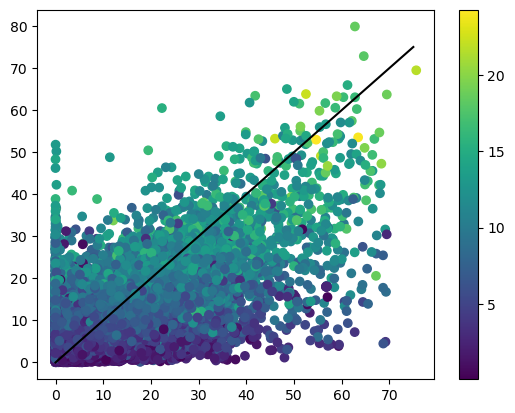

In [374]:
from matplotlib.colors import Normalize
import matplotlib.colors as cm

norm=Normalize(np.min(data['WindNorm']),np.max(data['WindNorm']))
cmap='viridis'

plt.scatter(data['TargetNorm'],data['OutputNorm'],c=data['WindNorm'],cmap=cmap, norm=norm, alpha=1)
plt.plot(np.arange(np.max(data['TargetNorm'])),'k')
plt.colorbar()
#plt.xlim([0,4])

# for the norms

In [364]:
#Loading the test data

testpd = pd.read_csv('../data/DRIFT_DATA_TEST.csv')
print(len(testpd))
target_bs=84789


testpd=testpd.drop(['year','month','day','x_EASE','y_EASE','id_buoy'],axis=1) #unwanted quantities

#ADDING THE COS AND SIN OF THE YEAR
testpd['sin']=np.sin(testpd['doy']*(2*np.pi/364))
testpd['cos']=np.cos(testpd['doy']*(2*np.pi/364))

#dropping the day of year
testpd=testpd.drop(['doy'], axis=1)

# adding the norms

testpd['windnorm']=np.sqrt(testpd['u_ERA5']**2+testpd['v_ERA5']**2)
testpd['buoynorm']=np.sqrt(testpd['u_buoy']**2+testpd['v_buoy']**2)




#######################################################################################################################################33
# NORMALIZATION STEP

# for the speeds, we substract the mean and divide by the standard deviation to get some cleaner distribution
speeds=['u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5', 'windnorm','buoynorm']

testmeans={}
teststds={}
for label in speeds:
    testmeans[label]=testpd[label].mean()
    teststds[label]=testpd[label].std()
    testpd[label]=(testpd[label]-testmeans[label])/teststds[label]

# SIC is already [0,1] and sea ice thickness is typically between 0 and idk 5 nothing is needed




testtarget = pd.DataFrame(testpd['buoynorm'])# had to reshape from u,v x rows to rows x u,v

testpd = testpd.drop(['u_buoy', 'v_buoy','buoynorm'],axis=1) # Take away the time of the year, wrong dtype and seems to be useless anyway
testlabels = [testtarget.columns, testpd.columns]
# we keep the day of year tho



testtensor = torch.tensor(testpd.values, dtype= torch.float32)
targetensor = torch.tensor(testtarget.values, dtype= torch.float32) 

testset=TensorDataset(targetensor,testtensor)
testloader=DataLoader(testset,batch_size=target_bs,shuffle=True)
print(testlabels)

###############################################################################################################################


testsample=next(iter(testloader))
#print(testsample)
testout=babygpu(testsample[1].to(device)).to('cpu')

def L2norm(u,v):
    return (u**2+v**2)**.5

################################################################
# Redimensionalize
outnorm=[]
targetnorm=[]
wind=[]
windnorm=[]
h=[]
sic=[]
sin=[]
cos=[]
print(testsample)

for k,i in enumerate(testout):
   #ice speeds
    outnorm.append(testout[k].item()*teststds['buoynorm']+testmeans['buoynorm'])
    #Target
    targetnorm.append(testsample[0][k].item()*teststds['buoynorm']+testmeans['buoynorm'])
    #INPUT PARAMETERS
    #wind norm
    windnorm.append(testsample[1][k][-1].item()*teststds['windnorm']+testmeans['windnorm'])
    #wind speeds
    uera=testsample[1][k][0].item()*teststds['u_ERA5']+testmeans['u_ERA5']
    vera=testsample[1][k][1].item()*teststds['v_ERA5']+testmeans['v_ERA5']
    wind.append([uera,vera])

    #thickness
    h.append(testsample[1][k][3].item())
    #concentration
    sic.append(testsample[1][k][2].item())
    #sin/cos
    sin.append(testsample[1][k][4].item())
    cos.append(testsample[1][k][5].item())

outnorm=np.array(outnorm)
targetnorm=np.array(targetnorm)
windnorm=np.array(windnorm)
wind=np.array(wind)
#doy=np.array(doy)

sic=np.array(sic)
h=np.array(h)
sin=np.array(sin)
cos=np.array(cos)

data= {
    'WindEra5': wind,
   # 'Day of Year': doy,
    'SIC':sic,
    'h':h,
    'TargetNorm':targetnorm,
    'OutputNorm':outnorm,
    'WindNorm': windnorm,

}

84789
[Index(['buoynorm'], dtype='object'), Index(['u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas', 'sin', 'cos', 'windnorm'], dtype='object')]
[tensor([[ 1.2925],
        [ 0.4149],
        [ 1.0000],
        ...,
        [-1.0873],
        [-0.0958],
        [-0.7594]]), tensor([[ 1.3502,  0.3437,  0.9754,  ..., -0.2225,  0.9749,  0.2416],
        [-0.3197, -0.5596,  1.0000,  ..., -0.9667, -0.2560, -1.0900],
        [ 2.0967,  1.2557,  0.9024,  ...,  0.7710,  0.6369,  1.9444],
        ...,
        [ 0.3260,  0.7531,  0.9420,  ...,  0.9976, -0.0690, -0.6333],
        [ 0.6776,  0.7499,  0.9645,  ..., -0.9851, -0.1718, -0.3450],
        [-0.4088,  0.0052,  1.0000,  ...,  0.0173,  0.9999, -1.3068]])]


5.239704127732322


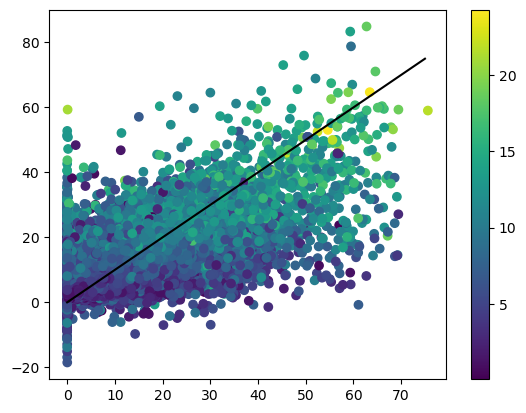

In [365]:
rMse = np.sqrt(np.mean((data['OutputNorm'] - data['TargetNorm'])**2))
print(rMse)

from matplotlib.colors import Normalize
import matplotlib.colors as cm

norm=Normalize(np.min(data['WindNorm']),np.max(data['WindNorm']))
cmap='viridis'

plt.scatter(data['TargetNorm'],data['OutputNorm'],c=data['WindNorm'],cmap=cmap, norm=norm, alpha=1)
plt.plot(np.arange(np.max(data['TargetNorm'])),'k')
plt.colorbar()
#plt.xlim([0,4])

# With XYEASE



In [385]:
#Loading the test data

testpd = pd.read_csv('../data/DRIFT_DATA_TEST.csv')
print(len(testpd))
target_bs=84789


testpd=testpd.drop(['year','month','day','id_buoy'],axis=1) #unwanted quantities

#ADDING THE COS AND SIN OF THE YEAR
testpd['sin']=np.sin(testpd['doy']*(2*np.pi/364))
testpd['cos']=np.cos(testpd['doy']*(2*np.pi/364))

#dropping the day of year
testpd=testpd.drop(['doy'], axis=1)

# adding the norms

testpd['windnorm']=np.sqrt(testpd['u_ERA5']**2+testpd['v_ERA5']**2)
testpd['buoynorm']=np.sqrt(testpd['u_buoy']**2+testpd['v_buoy']**2)




#######################################################################################################################################33
# NORMALIZATION STEP

# for the speeds, we substract the mean and divide by the standard deviation to get some cleaner distribution
speeds=['u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5', 'windnorm','buoynorm']

testmeans={}
teststds={}
for label in speeds:
    testmeans[label]=testpd[label].mean()
    teststds[label]=testpd[label].std()
    testpd[label]=(testpd[label]-testmeans[label])/teststds[label]

# SIC is already [0,1] and sea ice thickness is typically between 0 and idk 5 nothing is needed

# For the x,y, we simply divide by the max?
max_x=np.max(np.abs(testpd['x_EASE']))
testpd['x_EASE']=testpd['x_EASE']/max_x

max_y =np.max(np.abs(testpd['y_EASE']))
testpd['y_EASE']=testpd['y_EASE']/max_y



testtarget = pd.DataFrame(testpd['buoynorm'])# had to reshape from u,v x rows to rows x u,v

testpd = testpd.drop(['u_buoy', 'v_buoy','buoynorm'],axis=1) # Take away the time of the year, wrong dtype and seems to be useless anyway
testlabels = [testtarget.columns, testpd.columns]
# we keep the day of year tho



testtensor = torch.tensor(testpd.values, dtype= torch.float32)
targetensor = torch.tensor(testtarget.values, dtype= torch.float32) 

testset=TensorDataset(targetensor,testtensor)
testloader=DataLoader(testset,batch_size=target_bs,shuffle=True)
print(testlabels)

###############################################################################################################################


testsample=next(iter(testloader))
#print(testsample)
testout=babygpu(testsample[1].to(device)).to('cpu')

def L2norm(u,v):
    return (u**2+v**2)**.5

################################################################
# Redimensionalize
outnorm=[]
targetnorm=[]
wind=[]
windnorm=[]
h=[]
sic=[]
sin=[]
cos=[]
xease=[]
yease=[]
print(testsample)

for k,i in enumerate(testout):
   #ice speeds
    outnorm.append(testout[k].item()*teststds['buoynorm']+testmeans['buoynorm'])
    #Target
    targetnorm.append(testsample[0][k].item()*teststds['buoynorm']+testmeans['buoynorm'])
    #INPUT PARAMETERS
    #wind norm
    windnorm.append(testsample[1][k][-1].item()*teststds['windnorm']+testmeans['windnorm'])
    #wind speeds
    uera=testsample[1][k][2].item()*teststds['u_ERA5']+testmeans['u_ERA5']
    vera=testsample[1][k][3].item()*teststds['v_ERA5']+testmeans['v_ERA5']
    wind.append([uera,vera])

    #thickness
    h.append(testsample[1][k][5].item())
    #concentration
    sic.append(testsample[1][k][4].item())
    #sin/cos
    sin.append(testsample[1][k][6].item())
    cos.append(testsample[1][k][7].item())
    #X/Y
    xease.append(testsample[1][k][0].item()*max_x)
    yease.append(testsample[1][k][1].item()*max_y)

outnorm=np.array(outnorm)
targetnorm=np.array(targetnorm)
windnorm=np.array(windnorm)
wind=np.array(wind)
#doy=np.array(doy)

sic=np.array(sic)
h=np.array(h)
sin=np.array(sin)
cos=np.array(cos)
xease=np.array(xease)
yease=np.array(yease)

data= {
    'WindEra5': wind,
   # 'Day of Year': doy,
    'SIC':sic,
    'h':h,
    'TargetNorm':targetnorm,
    'OutputNorm':outnorm,
    'WindNorm': windnorm,
    'x':xease,
    'y':yease

}

84789
[Index(['buoynorm'], dtype='object'), Index(['x_EASE', 'y_EASE', 'u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas', 'sin',
       'cos', 'windnorm'],
      dtype='object')]
[tensor([[-0.1120],
        [-0.9076],
        [-0.4878],
        ...,
        [-0.7728],
        [-1.0846],
        [-0.7471]]), tensor([[ 0.6749,  0.4212, -0.4244,  ..., -0.9010,  0.4339, -1.1288],
        [ 0.6134,  0.6410,  0.2500,  ...,  0.5393,  0.8421, -0.4894],
        [ 0.7235,  0.6729, -0.3177,  ..., -0.5393,  0.8421, -0.5179],
        ...,
        [ 0.5708,  0.4553,  0.4422,  ...,  0.4339, -0.9010, -1.2185],
        [ 0.3896,  0.5715, -0.4577,  ..., -0.5099,  0.8602, -0.7054],
        [ 0.5934,  0.6141,  0.5826,  ...,  0.9999, -0.0173,  0.2375]])]


4.938792237533792


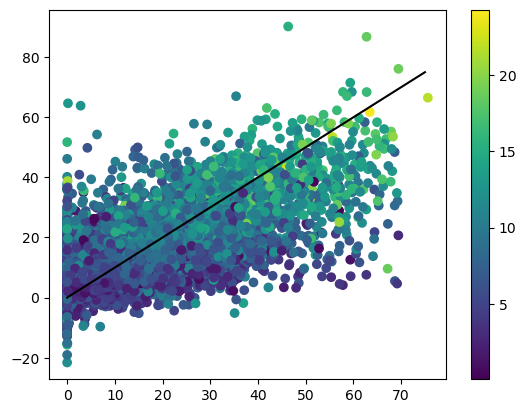

In [383]:
rMse = np.sqrt(np.mean((data['OutputNorm'] - data['TargetNorm'])**2))
print(rMse)

from matplotlib.colors import Normalize
import matplotlib.colors as cm

norm=Normalize(np.min(data['WindNorm']),np.max(data['WindNorm']))
cmap='viridis'

plt.scatter(data['TargetNorm'],data['OutputNorm'],c=data['WindNorm'],cmap=cmap, norm=norm, alpha=1)
plt.plot(np.arange(np.max(data['TargetNorm'])),'k')
plt.colorbar()

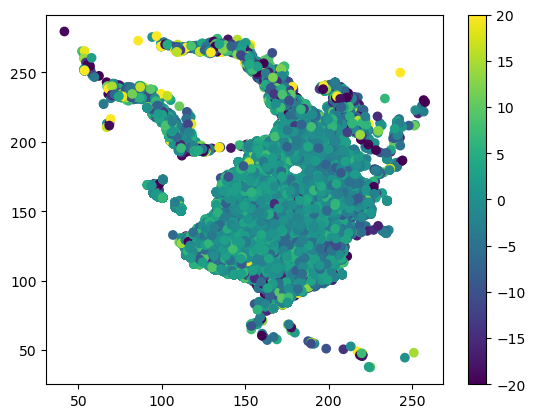

In [391]:
from matplotlib.colors import Normalize
import matplotlib.colors as cm
import cartopy.crs as ccrs

fig,ax =plt.subplots()#subplot_kw={'projection': ccrs.EqualEarth})
residual= (data['OutputNorm'] - data['TargetNorm'])
norm=Normalize(-20,20)#np.min(residual),np.max(residual))
cmap='viridis'

plt.scatter(data['x'],data['y'],c=residual,cmap=cmap, norm=norm, alpha=1)
#plt.plot(np.arange(np.max(data['TargetNorm'])),'k')
plt.colorbar()

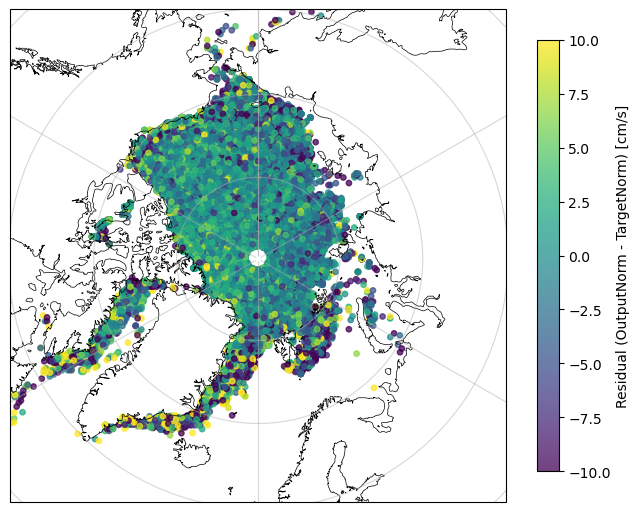

In [400]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
import numpy as np

# Load the EASE grid lat/lon (only needs to happen once)
lat_grid = pd.read_csv('../data/latitude_EASE.csv', header=None).values
lon_grid = pd.read_csv('../data/longitude_EASE.csv', header=None).values

# Convert your x,y grid indices to lat/lon for each sample
# (assumes data['x'], data['y'] are integer row/col indices into the grid)
lats = lat_grid[data['y'].astype(int), data['x'].astype(int)]
lons = lon_grid[data['y'].astype(int), data['x'].astype(int)]

residual = data['OutputNorm'] - data['TargetNorm']
norm = Normalize(-10, 10)
cmap = 'viridis'

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

# Set a sensible Arctic extent — adjust bounds to your buoy region
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add map context
ax.add_feature(cfeature.LAND, facecolor='black', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
ax.gridlines(alpha=.5)#draw_labels=True, linewidth=0.3, alpha=0.5)

sc = ax.scatter(
    lons, lats,
    c=residual, cmap=cmap, norm=norm,
    transform=ccrs.PlateCarree(),  # tells cartopy the data is in lon/lat, not the plot's projection
    s=15, alpha=0.75
)

plt.colorbar(sc, ax=ax, label='Residual (OutputNorm - TargetNorm) [cm/s]', shrink=0.7)
#plt.title('Spatial distribution of velocity-norm residuals')
plt.show()

# Claude output from discussing the plot
3. Interpreting the underprediction pattern (once validated on real test data)

What you're describing — predictions compressed toward the mean, increasingly underestimating as true speed grows, near-immobile ice not well captured — is a textbook symptom of regression to the mean under MSE loss, and it's worth understanding why it happens rather than just patching around it:

MSE's optimal prediction, for any given input, is the conditional mean of the target given that input. If two buoys experience nearly identical wind/ice conditions (as seen by your 5 features) but end up moving at very different speeds — because of turbulence, small-scale ice dynamics, or anything not captured by doy, u_ERA5, v_ERA5, sic_CDR, h_piomas — the model's best MSE-minimizing move is to predict somewhere in between, which systematically undershoots the high-speed cases and overshoots the near-zero cases whenever the true relationship is noisy/one-to-many rather than deterministic.
This effect is worse the more skewed your data is toward low speeds (which ice drift data typically is — lots of near-stationary/slow observations, fewer fast-moving events), since the loss is dominated by getting the common low-speed cases right, and high-speed cases contribute less to the total loss simply by being rarer.

Some concrete things worth trying, roughly cheapest-to-priciest:

Check the target distribution. Plot a histogram of TargetNorm. If it's heavily right-skewed (many near-zero, long tail of fast events), that confirms the imbalance story and explains a lot of the pattern on its own.
Weighted loss / resampling. Upweight samples with higher target speed in the loss, or oversample them during training, so the optimizer doesn't get to "ignore" them as a small minority.
Add features that actually distinguish immobile ice, rather than expecting the network to infer it from wind alone. You have bathymetry_EASE.csv sitting unused — distance to coast / water depth is a strong physical signal for landfast ice (ice anchored to the seabed or coast simply can't move regardless of wind), which is a plausible explanation for "model can't learn ice that cannot move." Right now nothing in your feature set explicitly encodes this, so the network has no way to distinguish "immobile because landfast" from "immobile because winds happen to be low."
Stratify your evaluation. Instead of one aggregate scatter/MSE, bin by true speed (e.g., quartiles) and report per-bin error. This tells you precisely where the model is weakest rather than eyeballing a cloud of points, and gives you a concrete metric to track as you try fixes.
Don't fully expect this to disappear. Even with all of the above, some shrinkage toward the mean is a fundamental property of MSE regression on noisy real-world data — it's not purely a bug to be eliminated, more a characteristic to be aware of and minimize. If your downstream use case cares specifically about capturing extreme/fast events well, you may eventually want to look at loss functions or evaluation metrics tailored to that instead of plain MSE.

# TO save weights


In [310]:
torch.save(babygpu.state_dict(), './/weights//babygpu_500E_1e3LR5e6_NORM.pt')

# To load weights for Sin/Cos


In [369]:
# creating my neural network

class firstNN(nn.Module):
    """Hummmm"""
    def __init__(self, n_inputs):
        """256->128->64"""
        super().__init__()
        self.fc1=nn.Linear(n_inputs,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,64)
        # self.fc4=nn.Linear(32,16)
        # self.fc5=nn.Linear(16,8)
        # self.fc6=nn.Linear(8,4)
        self.final=nn.Linear(64,2)

    def forward(self,x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=F.relu(self.fc3(x))
        # x=F.sigmoid(self.fc4(x))
        # x=F.sigmoid(self.fc5(x))
        # x=F.sigmoid(self.fc6(x))
        x=self.final(x)
        return x
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

print(device)
trainpd=pd.read_csv('../data/DRIFT_DATA_TRAIN.csv')

bs = 2**13 # batch size

trainpd=trainpd.drop(['year','month','day','x_EASE','y_EASE','id_buoy'],axis=1) #unwanted quantities

#ADDING THE COS AND SIN OF THE YEAR
trainpd['sin']=np.sin(trainpd['doy']*(2*np.pi/364))
trainpd['cos']=np.cos(trainpd['doy']*(2*np.pi/364))

#dropping the day of year
trainpd=trainpd.drop(['doy'],axis =1 )

# NORMALIZATION STEP

# for the speeds, we substract the mean and divide by the standard deviation to get some cleaner distribution
speeds=['u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5']

means={}
stds={}
for label in speeds:
    means[label]=trainpd[label].mean()
    stds[label]=trainpd[label].std()
    trainpd[label]=(trainpd[label]-trainpd[label].mean())/trainpd[label].std()


print(means)
print(stds)
# SIC is already [0,1] and sea ice thickness is typically between 0 and idk 5 nothing is needed



target = pd.DataFrame([trainpd['u_buoy'],trainpd['v_buoy']]).T# had to reshape from u,v x rows to rows x u,v

trainpd = trainpd.drop(['u_buoy', 'v_buoy'],axis=1) # Take away the time of the year, wrong dtype and seems to be useless anyway
labels = [target.columns, trainpd.columns]
# we keep the day of year tho

traintensor = torch.tensor(trainpd.values, dtype= torch.float32)
targetensor = torch.tensor(target.values, dtype= torch.float32) 
print(target.shape)
print(traintensor.shape)
baseline_mse = torch.mean(targetensor**2).item()  # predicting all-zeros
print("Baseline MSE (predict mean):", baseline_mse)
trainset=TensorDataset(targetensor,traintensor)
trainloader=DataLoader(trainset,batch_size=bs,shuffle=True)

babygpu= firstNN(n_inputs=traintensor.shape[1]).to(device)
print(babygpu)
babygpu.load_state_dict(torch.load('.//weights//babygpu_800E_1e3LR5e7_SinCosYear.pt', weights_only=True))
babygpu.eval()  # if you're doing inference, not continuing training

cuda
{'u_buoy': np.float64(-0.32911380120878647), 'v_buoy': np.float64(1.3688631602290797), 'u_ERA5': np.float64(-0.09414265660210988), 'v_ERA5': np.float64(0.34181398888012804)}
{'u_buoy': 8.060844323805954, 'v_buoy': 7.8546459505739765, 'u_ERA5': 4.31685881983416, 'v_ERA5': 4.122204959702637}
(339156, 2)
torch.Size([339156, 6])
Baseline MSE (predict mean): 0.999997079372406
firstNN(
  (fc1): Linear(in_features=6, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (final): Linear(in_features=64, out_features=2, bias=True)
)


firstNN(
  (fc1): Linear(in_features=6, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (final): Linear(in_features=64, out_features=2, bias=True)
)

# TO LOAD WEIGHT FOR THE NORMS


In [ ]:

class firstNN(nn.Module):
    """Hummmm"""
    def __init__(self, n_inputs):
        """MLP with Relu, 256->128->64
        linear 64->2"""
        super().__init__()
        self.fc1=nn.Linear(n_inputs,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,64)
        # self.fc4=nn.Linear(32,16)
        # self.fc5=nn.Linear(16,8)
        # self.fc6=nn.Linear(8,4)
        self.final=nn.Linear(64,1)
        #self.fourier=nn.Linear(n_inputs,n_inputs)

    def forward(self,x):
        #x=torch.cos(self.fourier(x))
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=F.relu(self.fc3(x))
        # x=F.sigmoid(self.fc4(x))
        # x=F.sigmoid(self.fc5(x))
        # x=F.sigmoid(self.fc6(x))
        x=self.final(x)
        return x


# Bring it to GPU
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

trainpd=pd.read_csv('../data/DRIFT_DATA_TRAIN.csv')

bs = 2**13 # batch size

trainpd=trainpd.drop(['year','month','day','x_EASE','y_EASE','id_buoy'],axis=1) #unwanted quantities

#ADDING THE COS AND SIN OF THE YEAR
trainpd['sin']=np.sin(trainpd['doy']*(2*np.pi/364))
trainpd['cos']=np.cos(trainpd['doy']*(2*np.pi/364))

#dropping the day of year
trainpd=trainpd.drop(['doy'],axis =1 )

# adding the norms

trainpd['windnorm']=np.sqrt(trainpd['u_ERA5']**2+trainpd['v_ERA5']**2)
trainpd['buoynorm']=np.sqrt(trainpd['u_buoy']**2+trainpd['v_buoy']**2)
# NORMALIZATION STEP

# for the speeds, we substract the mean and divide by the standard deviation to get some cleaner distribution
speeds=['u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5', 'windnorm','buoynorm']

means={}
stds={}
for label in speeds:
    means[label]=trainpd[label].mean()
    stds[label]=trainpd[label].std()
    trainpd[label]=(trainpd[label]-trainpd[label].mean())/trainpd[label].std()


print(means)
print(stds)
# SIC is already [0,1] and sea ice thickness is typically between 0 and idk 5 nothing is needed




target = pd.DataFrame(trainpd['buoynorm'])# 

trainpd = trainpd.drop(['u_buoy', 'v_buoy','buoynorm'],axis=1) # Take away the time of the year, wrong dtype and seems to be useless anyway
labels = [target.columns, trainpd.columns]
# we keep the day of year tho



traintensor = torch.tensor(trainpd.values, dtype= torch.float32)
targetensor = torch.tensor(target.values, dtype= torch.float32) 

print('Labels: ', labels)

baseline_mse = torch.mean(targetensor**2).item()  # predicting all-zeros
print("Baseline MSE (predict mean):", baseline_mse)

# Building the dataset and loader
trainset=TensorDataset(targetensor,traintensor)
trainloader=DataLoader(trainset,batch_size=bs,shuffle=True)


babygpu= firstNN(n_inputs=traintensor.shape[1]).to(device)

print(babygpu)
babygpu.load_state_dict(torch.load('.//weights//babygpu_500E_1e3LR5e6_NORM.pt', weights_only=True))
babygpu.eval()  # if you're doing inference, not continuing training

{'u_buoy': np.float64(-0.32911380120878647), 'v_buoy': np.float64(1.3688631602290797), 'u_ERA5': np.float64(-0.09414265660210988), 'v_ERA5': np.float64(0.34181398888012804), 'windnorm': np.float64(5.35318035300248), 'buoynorm': np.float64(8.347371797306305)}
{'u_buoy': 8.060844323805954, 'v_buoy': 7.8546459505739765, 'u_ERA5': 4.31685881983416, 'v_ERA5': 4.122204959702637, 'windnorm': 2.664004397121848, 'buoynorm': 7.67958077899918}
Labels:  [Index(['buoynorm'], dtype='object'), Index(['u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas', 'sin', 'cos', 'windnorm'], dtype='object')]
Baseline MSE (predict mean): 0.999997079372406
firstNN(
  (fc1): Linear(in_features=7, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (final): Linear(in_features=64, out_features=1, bias=True)
)


RuntimeError: Error(s) in loading state_dict for firstNN:
	size mismatch for fc1.weight: copying a param with shape torch.Size([256, 8]) from checkpoint, the shape in current model is torch.Size([256, 7]).

# TO LOAD with XYEASE

In [ ]:

class firstNN(nn.Module):
    """Hummmm"""
    def __init__(self, n_inputs):
        """MLP with Relu, 256->128->64
        linear 64->2"""
        super().__init__()
        self.fc1=nn.Linear(n_inputs,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,64)
        # self.fc4=nn.Linear(32,16)
        # self.fc5=nn.Linear(16,8)
        # self.fc6=nn.Linear(8,4)
        self.final=nn.Linear(64,1)
        #self.fourier=nn.Linear(n_inputs,n_inputs)

    def forward(self,x):
        #x=torch.cos(self.fourier(x))
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=F.relu(self.fc3(x))
        # x=F.sigmoid(self.fc4(x))
        # x=F.sigmoid(self.fc5(x))
        # x=F.sigmoid(self.fc6(x))
        x=self.final(x)
        return x


# Bring it to GPU
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

babygpu= firstNN(n_inputs=9).to(device)

print(babygpu)
babygpu.load_state_dict(torch.load('.//weights//babygpu_500E_1e3LR5e6_NORM.pt', weights_only=True))
babygpu.eval()  # if you're doing inference, not continuing training